Accuracy: 100.0 %


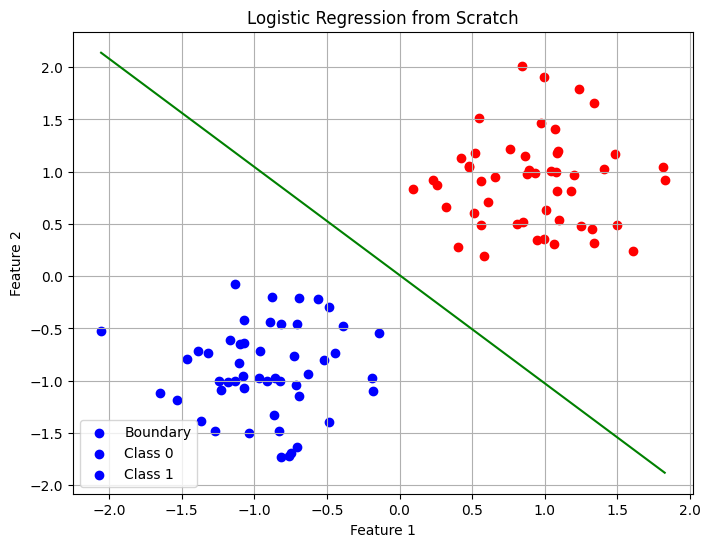

In [1]:
# Logistic Regression from Scratch
# 2 Features, 100 Samples, 2 Classes, with Visualization

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Generate Dataset
# -----------------------------
np.random.seed(42)

# Class 0 (50 samples)
X0 = np.random.randn(50, 2) + np.array([2, 2])

# Class 1 (50 samples)
X1 = np.random.randn(50, 2) + np.array([6, 6])

# Combine data
X = np.vstack((X0, X1))          # Shape = (100,2)
y = np.hstack((np.zeros(50), np.ones(50)))   # Labels

# -----------------------------
# Step 2: Normalize Features
# -----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0)

# -----------------------------
# Step 3: Initialize Parameters
# -----------------------------
m, n = X.shape
weights = np.zeros(n)
bias = 0

learning_rate = 0.1
epochs = 1000

# -----------------------------
# Step 4: Sigmoid Function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Step 5: Training using Gradient Descent
# -----------------------------
for i in range(epochs):
    
    # Linear equation
    z = np.dot(X, weights) + bias
    
    # Prediction
    y_pred = sigmoid(z)
    
    # Gradients
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)
    
    # Update parameters
    weights -= learning_rate * dw
    bias -= learning_rate * db

# -----------------------------
# Step 6: Predictions
# -----------------------------
z = np.dot(X, weights) + bias
y_pred = sigmoid(z)
predictions = (y_pred >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(predictions == y) * 100
print("Accuracy:", accuracy, "%")

# -----------------------------
# Step 7: Visualization
# -----------------------------
plt.figure(figsize=(8,6))

# Plot points
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], color='blue')
    else:
        plt.scatter(X[i,0], X[i,1], color='red')

# Decision Boundary
x_values = np.array([X[:,0].min(), X[:,0].max()])
y_values = -(weights[0]*x_values + bias) / weights[1]

plt.plot(x_values, y_values, color='green', label='Decision Boundary')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression from Scratch")
plt.legend(["Boundary", "Class 0", "Class 1"])
plt.grid(True)
plt.show()

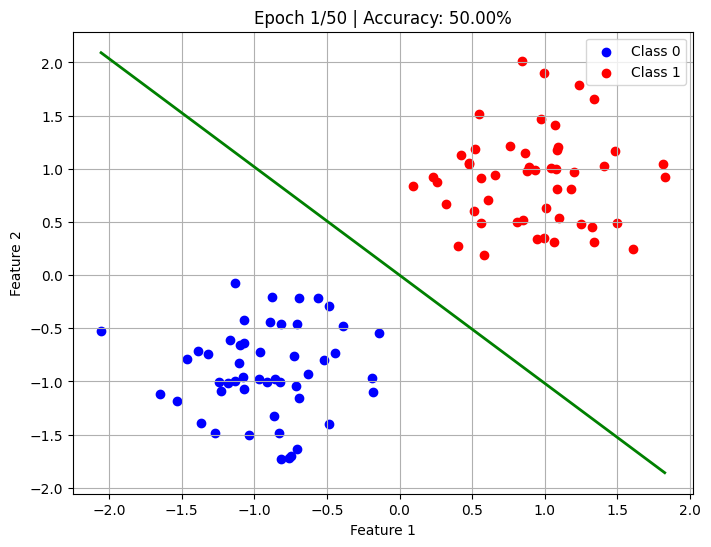

In [3]:
# Logistic Regression from Scratch
# 2 Features, 100 Samples, 2 Classes
# Visualization of EACH EPOCH (50 Epochs)

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Create Dataset
# ----------------------------
np.random.seed(42)

# Class 0
X0 = np.random.randn(50, 2) + np.array([2, 2])

# Class 1
X1 = np.random.randn(50, 2) + np.array([6, 6])

X = np.vstack((X0, X1))
y = np.hstack((np.zeros(50), np.ones(50)))

# ----------------------------
# Step 2: Normalize Data
# ----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0)

# ----------------------------
# Step 3: Parameters
# ----------------------------
m, n = X.shape
weights = np.zeros(n)
bias = 0

learning_rate = 0.2
epochs = 50

# ----------------------------
# Step 4: Sigmoid Function
# ----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ----------------------------
# Step 5: Plot Setup
# ----------------------------
plt.ion()   # Interactive mode ON
fig, ax = plt.subplots(figsize=(8,6))

# ----------------------------
# Step 6: Training + Visualize Each Epoch
# ----------------------------
for epoch in range(epochs):

    # Forward pass
    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)

    # Gradients
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)

    # Update
    weights -= learning_rate * dw
    bias -= learning_rate * db

    # Clear graph
    ax.clear()

    # Plot class 0
    ax.scatter(X[y==0][:,0], X[y==0][:,1], color='blue', label='Class 0')

    # Plot class 1
    ax.scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Class 1')

    # Decision boundary
    x_values = np.array([X[:,0].min(), X[:,0].max()])

    if weights[1] != 0:
        y_values = -(weights[0]*x_values + bias) / weights[1]
        ax.plot(x_values, y_values, color='green', linewidth=2)

    # Accuracy
    preds = (y_pred >= 0.5).astype(int)
    acc = np.mean(preds == y) * 100

    # Labels
    ax.set_title(f"Epoch {epoch+1}/50 | Accuracy: {acc:.2f}%")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    ax.grid(True)

    plt.pause(0.4)   # Delay to show each epoch

plt.ioff()
plt.show()